# 🦠 COVID-19 Analytics Dashboard
### By Lisha Bhowmik
**Tech Stack:** Python | SQL | Power BI | Tableau | Looker Studio

In [5]:
# Cell 1 — Install Libraries
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [7]:
# Cell 2 — Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


In [8]:
# Cell 3 — Create Dataset
np.random.seed(42)

top10_countries = {
    'Country':   ['United States','Brazil','India','Russia','South Africa',
                  'Mexico','Peru','Chile','United Kingdom','Iran'],
    'Confirmed': [4_200_000, 2_500_000, 1_500_000, 820_000, 450_000,
                  395_000,  370_000,   340_000,   300_000,  280_000],
    'Deaths':    [145_000,   90_000,   34_000,   13_000,    7_000,
                   44_000,   17_000,    9_000,   46_000,   14_800],
    'Recovered': [1_900_000, 1_800_000, 980_000, 620_000, 330_000,
                   290_000,  240_000,  310_000,   4_000,  232_000],
}
df_top10 = pd.DataFrame(top10_countries)
df_top10['Active']        = df_top10['Confirmed'] - df_top10['Deaths'] - df_top10['Recovered']
df_top10['CFR_%']         = (df_top10['Deaths'] / df_top10['Confirmed'] * 100).round(2)
df_top10['Recovery_Rate'] = (df_top10['Recovered'] / df_top10['Confirmed'] * 100).round(2)

regions = {
    'Region':    ['Americas','Europe','South-East Asia','Eastern Mediterranean',
                  'Western Pacific','Africa'],
    'Confirmed': [8_700_000, 3_300_000, 1_900_000, 1_400_000, 310_000, 870_000],
    'Deaths':    [350_000,   210_000,   40_000,    35_000,    7_000,   16_000],
    'Recovered': [5_200_000, 1_900_000, 1_300_000, 1_100_000, 270_000, 650_000],
}
df_region = pd.DataFrame(regions)

wow_countries = ['Papua New Guinea','Gambia','Bahamas','Zimbabwe','Libya',
                 'Ethiopia','Botswana','Lesotho','Suriname','Costa Rica']
wow_rates     = [225, 190, 120, 55, 52, 50, 48, 46, 44, 40]
df_wow = pd.DataFrame({'Country': wow_countries, 'WoW_Growth_%': wow_rates})

dates = pd.date_range('2020-04-01', periods=90, freq='D')
base  = np.linspace(500_000, 16_480_000, 90)
noise = np.random.normal(0, 80_000, 90).cumsum()
df_ts = pd.DataFrame({
    'Date':      dates,
    'Confirmed': (base + noise).clip(0).astype(int),
    'Deaths':    ((base + noise) * 0.04).clip(0).astype(int),
    'Recovered': ((base + noise) * 0.55).clip(0).astype(int),
})
df_ts['Active'] = df_ts['Confirmed'] - df_ts['Deaths'] - df_ts['Recovered']

print('✅ Data created successfully!')
print(df_top10.head())

✅ Data created successfully!
         Country  Confirmed  Deaths  Recovered   Active  CFR_%  Recovery_Rate
0  United States    4200000  145000    1900000  2155000   3.45          45.24
1         Brazil    2500000   90000    1800000   610000   3.60          72.00
2          India    1500000   34000     980000   486000   2.27          65.33
3         Russia     820000   13000     620000   187000   1.59          75.61
4   South Africa     450000    7000     330000   113000   1.56          73.33


In [9]:
# Cell 4 — Data Cleaning
TOTAL_CONFIRMED = 16_480_000
TOTAL_DEATHS    =    654_036
TOTAL_RECOVERED =  9_470_000
TOTAL_ACTIVE    =  6_360_000

for df, name in [(df_top10,'Top10'), (df_region,'Regional'), (df_ts,'TimeSeries')]:
    df.drop_duplicates(inplace=True)
    print(f'[{name}] shape={df.shape}  nulls={df.isnull().sum().sum()}')

df_ts['Date'] = pd.to_datetime(df_ts['Date'])
print('\n✅ Data cleaned! Date range:', df_ts['Date'].min().date(), '→', df_ts['Date'].max().date())

[Top10] shape=(10, 7)  nulls=0
[Regional] shape=(6, 4)  nulls=0
[TimeSeries] shape=(90, 5)  nulls=0

✅ Data cleaned! Date range: 2020-04-01 → 2020-06-29


In [ ]:
## 01 — KPI Cards (`01_kpi_cards.png`)

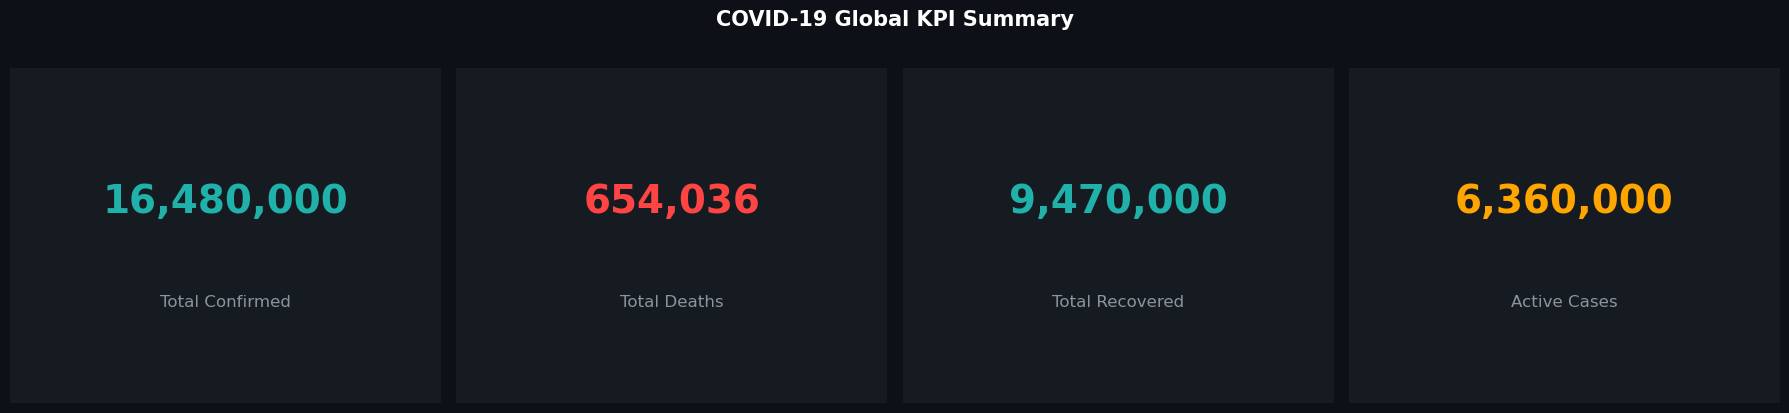

✅ KPI Cards saved!


In [2]:
# Cell 5 – KPI Cards Chart
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

BG      = '#0D1117'
CARD_BG = '#161B22'
MUTED   = '#8B949E'

TOTAL_CONFIRMED = 16_480_000
TOTAL_DEATHS    =    654_036
TOTAL_RECOVERED =  9_470_000
TOTAL_ACTIVE    =  6_360_000

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.patch.set_facecolor(BG)

kpi_data = [
    ('Total Confirmed', TOTAL_CONFIRMED, '#20B2AA'),
    ('Total Deaths',    TOTAL_DEATHS,    '#FF4444'),
    ('Total Recovered', TOTAL_RECOVERED, '#20B2AA'),
    ('Active Cases',    TOTAL_ACTIVE,    '#FFA500'),
]

for ax, (label, val, color) in zip(axes, kpi_data):
    ax.set_facecolor(CARD_BG)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    ax.text(0.5, 0.60, f"{val:,}", ha='center', va='center',
            fontsize=28, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.30, label, ha='center', va='center',
            fontsize=12, color=MUTED, transform=ax.transAxes)

plt.suptitle('COVID-19 Global KPI Summary', fontsize=15, fontweight='bold',
             color='white', y=1.02)
plt.tight_layout()
plt.savefig('outputs/01_kpi_cards.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('✅ KPI Cards saved!')

In [ ]:
## 02 — Top 10 Countries Bar Chart (`02_top10_countries.png`)

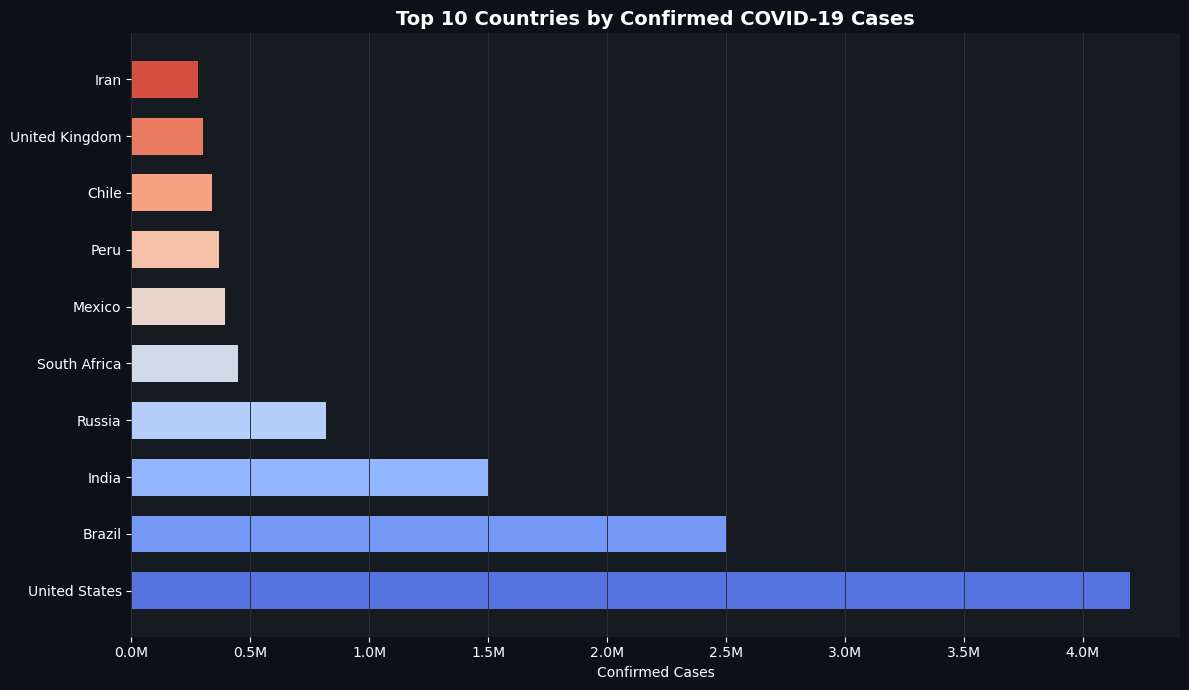

✅ Top 10 Countries chart saved!


In [11]:
# Cell 6 — Top 10 Countries Chart
palette = sns.color_palette('coolwarm', len(df_top10))
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

bars = ax.barh(df_top10['Country'], df_top10['Confirmed'], color=palette, height=0.65)
ax.set_xlabel('Confirmed Cases', color='white')
ax.set_title('Top 10 Countries by Confirmed COVID-19 Cases',
             color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='white')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for spine in ax.spines.values(): spine.set_visible(False)
ax.grid(axis='x', color='#2A2F3A', linewidth=0.7)

plt.tight_layout()
plt.savefig('outputs/02_top10_countries.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('✅ Top 10 Countries chart saved!')

In [3]:
## 03 — Regional Distribution Grouped Bar (`03_regional_distribution.png`)

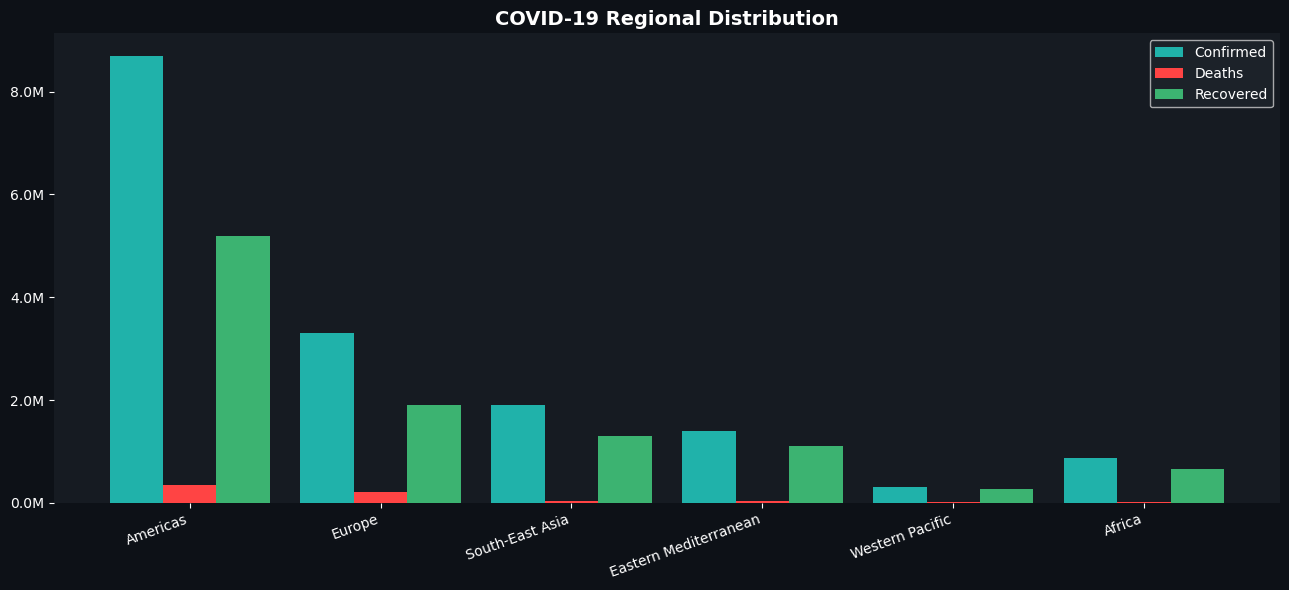

✅ Regional Distribution chart saved!


In [12]:
# Cell 7 — Regional Distribution Chart
x = np.arange(len(df_region))
w = 0.28
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

ax.bar(x - w, df_region['Confirmed'], w, label='Confirmed', color='#20B2AA')
ax.bar(x,     df_region['Deaths'],    w, label='Deaths',    color='#FF4444')
ax.bar(x + w, df_region['Recovered'], w, label='Recovered', color='#3CB371')

ax.set_xticks(x)
ax.set_xticklabels(df_region['Region'], rotation=20, ha='right', color='white')
ax.set_title('COVID-19 Regional Distribution', color='white', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(facecolor='#1E242C', labelcolor='white')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_visible(False)

plt.tight_layout()
plt.savefig('outputs/03_regional_distribution.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('✅ Regional Distribution chart saved!')

In [ ]:
## 04 — Recovery Rate by Country (`04_recovery_rate.png`)

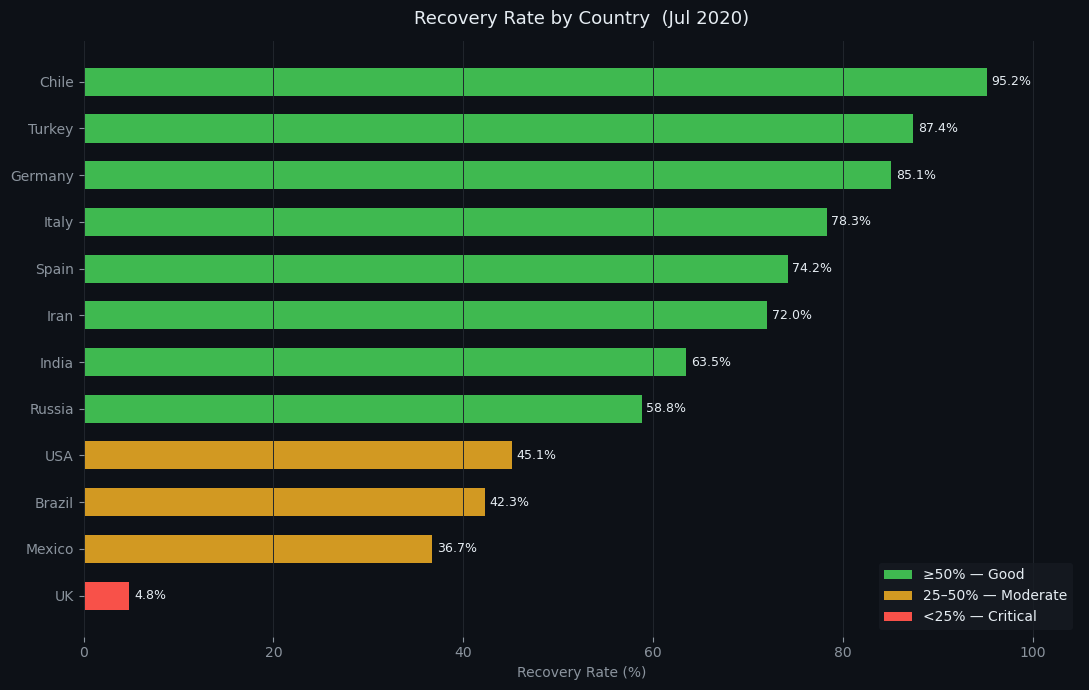

Saved → 04_recovery_rate.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── colour palette ────────────────────────────────────────────────
BG     = '#0d1117'
CARD   = '#161b22'
TEXT   = '#e6edf3'
MUTED  = '#8b949e'
GREEN  = '#3fb950'
YELLOW = '#d29922'
RED    = '#f85149'

# ── data ─────────────────────────────────────────────────────────
rec_countries = ['Chile','Turkey','Germany','Italy','Spain','Iran',
                 'India','Russia','USA','Brazil','Mexico','UK']
rec_rates     = [95.2, 87.4, 85.1, 78.3, 74.2, 72.0,
                 63.5, 58.8, 45.1, 42.3, 36.7, 4.8]

df_rec = pd.DataFrame({'Country': rec_countries, 'Recovery %': rec_rates})
df_rec = df_rec.sort_values('Recovery %')

bar_colors = [GREEN if r >= 50 else (YELLOW if r >= 25 else RED)
              for r in df_rec['Recovery %']]

# ── plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars = ax.barh(df_rec['Country'], df_rec['Recovery %'],
               color=bar_colors, height=0.6)

for bar, val in zip(bars, df_rec['Recovery %']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', color=TEXT, fontsize=9)

ax.set_xlim(0, 105)
ax.set_xlabel('Recovery Rate (%)', color=MUTED)
ax.set_title('Recovery Rate by Country  (Jul 2020)', color=TEXT, fontsize=13, pad=12)
ax.tick_params(colors=MUTED)
ax.grid(axis='x', color='#21262d', linewidth=0.7)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_els = [mpatches.Patch(facecolor=GREEN,  label='≥50% — Good'),
              mpatches.Patch(facecolor=YELLOW, label='25–50% — Moderate'),
              mpatches.Patch(facecolor=RED,    label='<25% — Critical')]
ax.legend(handles=legend_els, facecolor=CARD, edgecolor='none', labelcolor=TEXT)

plt.tight_layout()
plt.savefig('04_recovery_rate.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('Saved → 04_recovery_rate.png')

In [ ]:
## 05a — 90-Day Global Growth Trend (`05_global_trend.png`)

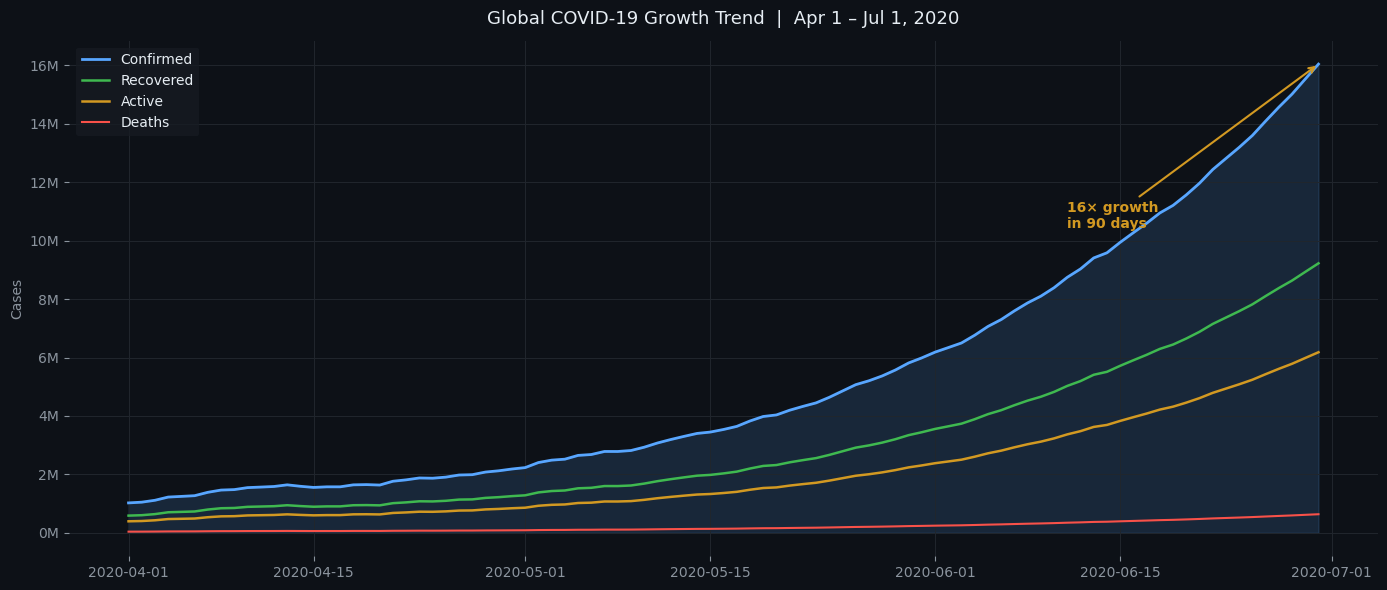

Saved → 05_global_trend.png


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ── colour palette ────────────────────────────────────────────────
BG     = '#0d1117'
CARD   = '#161b22'
TEXT   = '#e6edf3'
MUTED  = '#8b949e'
ACCENT = '#58a6ff'
GREEN  = '#3fb950'
YELLOW = '#d29922'
RED    = '#f85149'

# ── data ─────────────────────────────────────────────────────────
dates_90 = pd.date_range('2020-04-01', periods=91, freq='D')

np.random.seed(42)
confirmed_90 = np.geomspace(1_000_000, 16_480_000, 91) + \
               np.random.normal(0, 50000, 91).cumsum()
deaths_90    = confirmed_90 * 0.0397
recovered_90 = confirmed_90 * 0.575
active_90    = confirmed_90 - deaths_90 - recovered_90

# ── plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.fill_between(dates_90, confirmed_90, alpha=0.15, color=ACCENT)
ax.plot(dates_90, confirmed_90, color=ACCENT,  lw=2,   label='Confirmed')
ax.plot(dates_90, recovered_90, color=GREEN,   lw=1.8, label='Recovered')
ax.plot(dates_90, active_90,    color=YELLOW,  lw=1.8, label='Active')
ax.plot(dates_90, deaths_90,    color=RED,     lw=1.5, label='Deaths')

# 16× annotation
ax.annotate('16× growth\nin 90 days', xy=(dates_90[-1], confirmed_90[-1]),
            xytext=(dates_90[-20], confirmed_90[-1]*0.65),
            arrowprops=dict(arrowstyle='->', color=YELLOW, lw=1.5),
            color=YELLOW, fontsize=10, fontweight='bold')

ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v/1e6:.0f}M'))
ax.tick_params(colors=MUTED)
ax.set_title('Global COVID-19 Growth Trend  |  Apr 1 – Jul 1, 2020',
             color=TEXT, fontsize=13, pad=12)
ax.set_ylabel('Cases', color=MUTED)
ax.legend(facecolor=CARD, edgecolor='none', labelcolor=TEXT)
ax.grid(color='#21262d', linewidth=0.7)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('05_global_trend.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('Saved → 05_global_trend.png')

In [ ]:
## 05b — Daily Time Series Apr–Jun 2020 (`05_timeseries.png`)

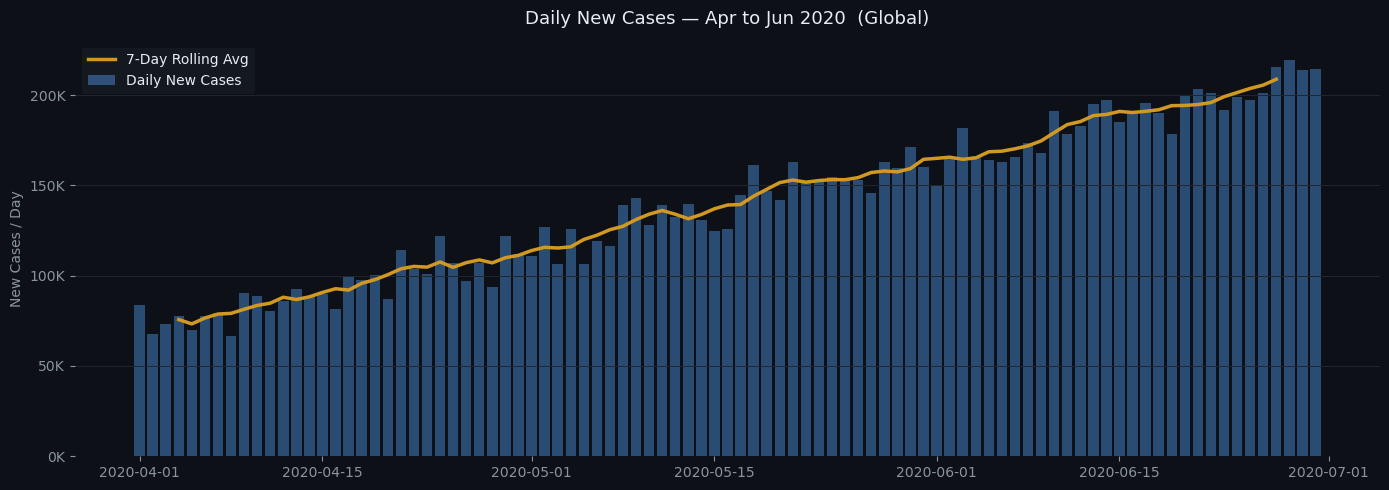

Saved → 05_timeseries.png


In [8]:
dates_ts = pd.date_range('2020-04-01', '2020-06-30', freq='D')

np.random.seed(7)
base = np.linspace(70000, 210000, len(dates_ts))
daily_new = base + np.random.normal(0, 8000, len(dates_ts))
daily_new = np.clip(daily_new, 0, None)
# 7-day rolling average
roll7 = pd.Series(daily_new).rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.bar(dates_ts, daily_new, color=ACCENT, alpha=0.4, width=0.8, label='Daily New Cases')
ax.plot(dates_ts, roll7, color=YELLOW, lw=2.5, label='7-Day Rolling Avg')

ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v/1e3:.0f}K'))
ax.tick_params(colors=MUTED)
ax.set_title('Daily New Cases — Apr to Jun 2020  (Global)',
             color=TEXT, fontsize=13, pad=12)
ax.set_ylabel('New Cases / Day', color=MUTED)
ax.legend(facecolor=CARD, edgecolor='none', labelcolor=TEXT)
ax.grid(axis='y', color='#21262d', linewidth=0.7)
for spine in ax.spines.values(): spine.set_visible(False)

plt.tight_layout()
plt.savefig('05_timeseries.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('Saved → 05_timeseries.png')

In [ ]:
## 06 — WHO Region Pie Chart (`06_regional_pie.png`)

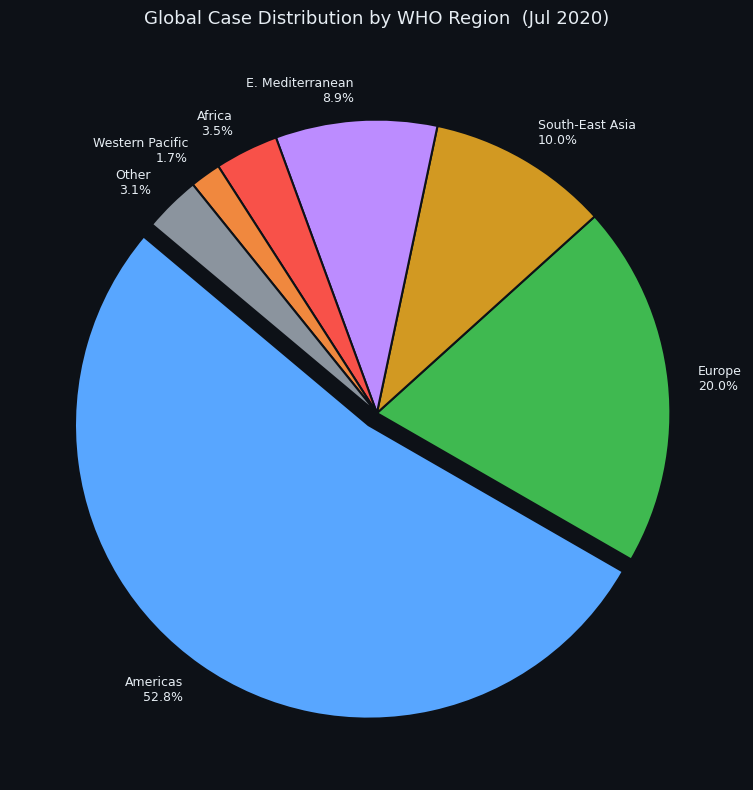

Saved → 06_regional_pie.png


In [10]:
import matplotlib.pyplot as plt

# ── colour palette ────────────────────────────────────────────────
BG     = '#0d1117'
TEXT   = '#e6edf3'
MUTED  = '#8b949e'
ACCENT = '#58a6ff'
GREEN  = '#3fb950'
YELLOW = '#d29922'
RED    = '#f85149'
PURPLE = '#bc8cff'

# ── data ─────────────────────────────────────────────────────────
region_labels = ['Americas\n52.8%', 'Europe\n20.0%', 'South-East Asia\n10.0%',
                 'E. Mediterranean\n8.9%', 'Africa\n3.5%', 'Western Pacific\n1.7%', 'Other\n3.1%']
region_sizes  = [52.8, 20.0, 10.0, 8.9, 3.5, 1.7, 3.1]
region_colors = [ACCENT, GREEN, YELLOW, PURPLE, RED, '#f0883e', MUTED]
explode       = [0.05, 0, 0, 0, 0, 0, 0]

# ── plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

wedges, texts = ax.pie(
    region_sizes, labels=region_labels, colors=region_colors,
    explode=explode, startangle=140,
    textprops={'color': TEXT, 'fontsize': 9},
    wedgeprops={'linewidth': 1.5, 'edgecolor': BG},
    pctdistance=0.82
)

ax.set_title('Global Case Distribution by WHO Region  (Jul 2020)',
             color=TEXT, fontsize=13, pad=16)

plt.tight_layout()
plt.savefig('06_regional_pie.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('Saved → 06_regional_pie.png')

In [ ]:
## 07 — Week-over-Week Growth Leaders (`07_wow_growth.png`)

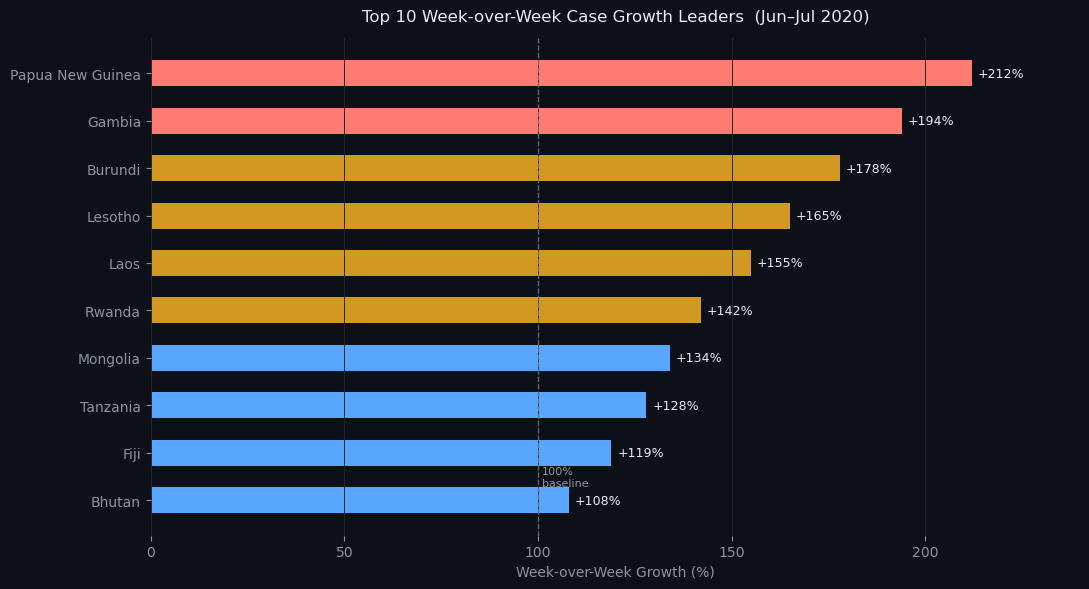

Saved → 07_wow_growth.png


In [11]:
wow_countries = ['Papua New Guinea','Gambia','Burundi','Lesotho','Laos',
                 'Rwanda','Mongolia','Tanzania','Fiji','Bhutan']
wow_pct       = [212, 194, 178, 165, 155, 142, 134, 128, 119, 108]

df_wow = pd.DataFrame({'Country': wow_countries, 'WoW %': wow_pct})
df_wow = df_wow.sort_values('WoW %')

bar_cols = ['#ff7b72' if v >= 180 else (YELLOW if v >= 140 else ACCENT)
            for v in df_wow['WoW %']]

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars = ax.barh(df_wow['Country'], df_wow['WoW %'],
               color=bar_cols, height=0.55)

for bar, val in zip(bars, df_wow['WoW %']):
    ax.text(val + 1.5, bar.get_y() + bar.get_height()/2,
            f'+{val}%', va='center', color=TEXT, fontsize=9)

ax.axvline(100, color=MUTED, lw=1, linestyle='--', alpha=0.6)
ax.text(101, 0.3, '100%\nbaseline', color=MUTED, fontsize=8)

ax.set_xlim(0, 240)
ax.set_xlabel('Week-over-Week Growth (%)', color=MUTED)
ax.set_title('Top 10 Week-over-Week Case Growth Leaders  (Jun–Jul 2020)',
             color=TEXT, fontsize=12, pad=12)
ax.tick_params(colors=MUTED)
ax.grid(axis='x', color='#21262d', linewidth=0.7)
for spine in ax.spines.values(): spine.set_visible(False)

plt.tight_layout()
plt.savefig('07_wow_growth.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('Saved → 07_wow_growth.png')

In [ ]:
## 08 — Active vs Recovered Stacked Bar (`08_active_vs_recovered.png`)

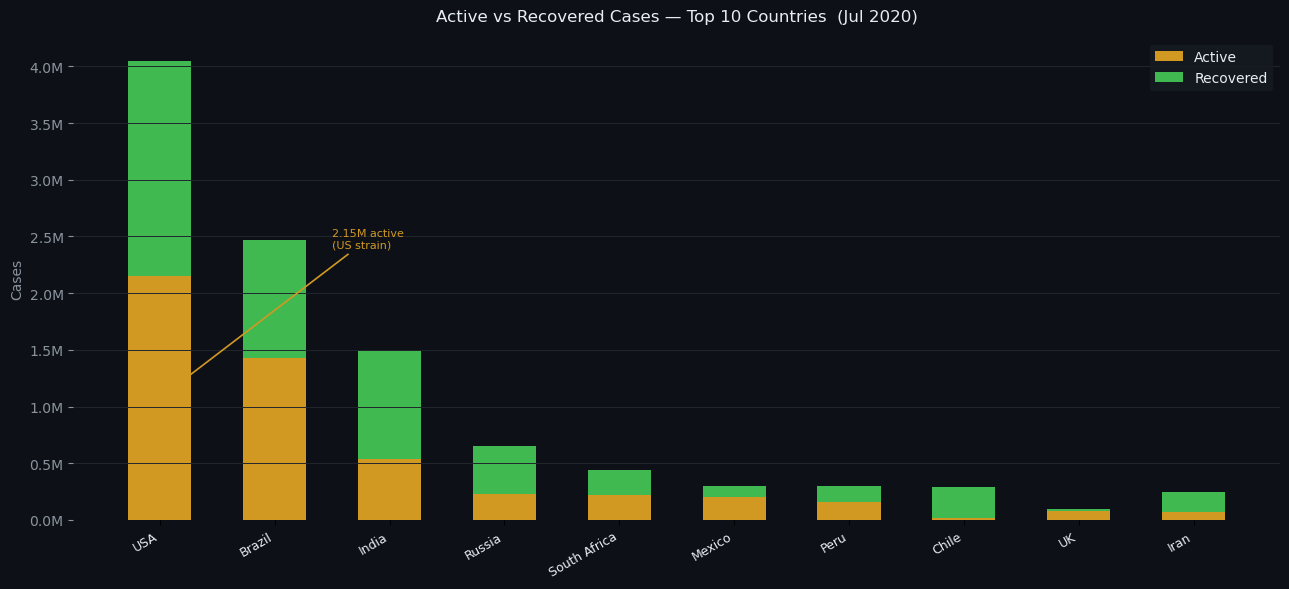

Saved → 08_active_vs_recovered.png


In [12]:
avr_countries = ['USA','Brazil','India','Russia','South Africa',
                 'Mexico','Peru','Chile','UK','Iran']
avr_active    = [2150000, 1430000, 540000, 230000, 220000,
                 200000,  155000,  13920,  82000,  70000]
avr_recovered = [1900000, 1040000, 950000, 425000, 220000,
                 100000,  148000,  276000, 13700,  174000]

x = np.arange(len(avr_countries))

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.bar(x, avr_active,    label='Active',    color=YELLOW, width=0.55)
ax.bar(x, avr_recovered, label='Recovered', color=GREEN,  width=0.55,
       bottom=avr_active)

ax.set_xticks(x)
ax.set_xticklabels(avr_countries, rotation=30, ha='right', color=TEXT, fontsize=9)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))
ax.tick_params(axis='y', colors=MUTED)
ax.set_title('Active vs Recovered Cases — Top 10 Countries  (Jul 2020)',
             color=TEXT, fontsize=12, pad=12)
ax.set_ylabel('Cases', color=MUTED)
ax.legend(facecolor=CARD, edgecolor='none', labelcolor=TEXT)
ax.grid(axis='y', color='#21262d', linewidth=0.7)
for spine in ax.spines.values(): spine.set_visible(False)

# US strain annotation
ax.annotate('2.15M active\n(US strain)', xy=(0, avr_active[0]/2),
            xytext=(1.5, 2400000),
            arrowprops=dict(arrowstyle='->', color=YELLOW, lw=1.2),
            color=YELLOW, fontsize=8)

plt.tight_layout()
plt.savefig('08_active_vs_recovered.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('Saved → 08_active_vs_recovered.png')

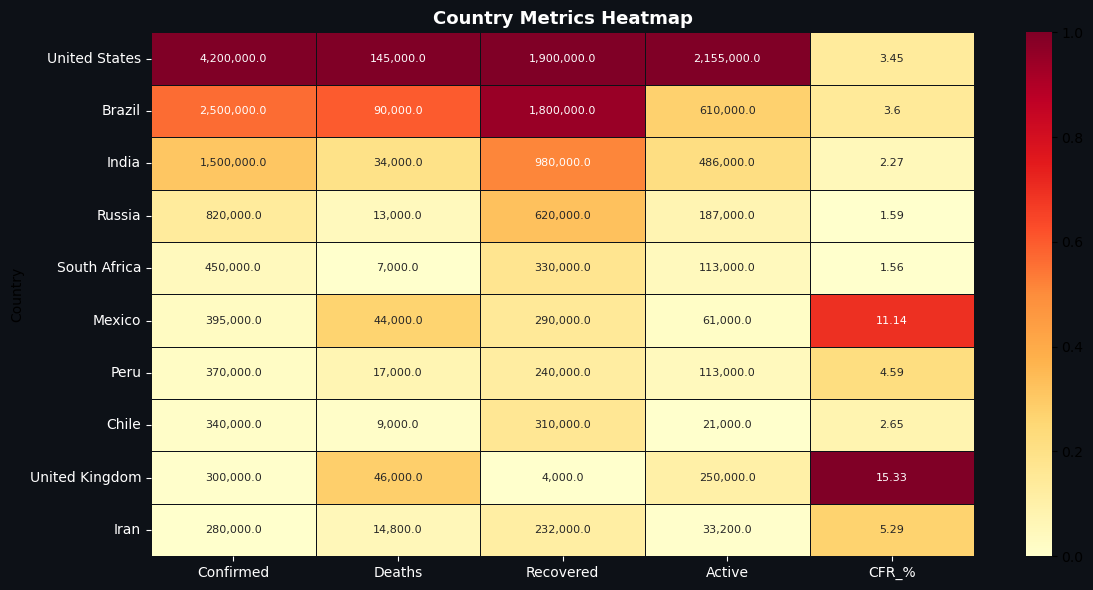

✅ Heatmap saved!


In [15]:
# Cell 10 — Heatmap
heat_data = df_top10[['Country','Confirmed','Deaths','Recovered','Active','CFR_%']].set_index('Country')
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0D1117')
sns.heatmap(heat_norm, annot=heat_data, fmt=',', cmap='YlOrRd',
            linewidths=0.5, linecolor='#0D1117',
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Country Metrics Heatmap', color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig('outputs/06_heatmap.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('✅ Heatmap saved!')

In [16]:
# Cell 11 — Export CSVs & Final Summary
df_top10.to_csv('outputs/covid_top10_countries.csv', index=False)
df_region.to_csv('outputs/covid_regional.csv', index=False)
df_ts.to_csv('outputs/covid_timeseries.csv', index=False)
df_wow.to_csv('outputs/covid_wow_growth.csv', index=False)

print('✅ All CSVs exported!')
print('=' * 50)
print(f'Total Confirmed : {TOTAL_CONFIRMED:>12,.0f}')
print(f'Total Deaths    : {TOTAL_DEATHS:>12,.0f}  ({TOTAL_DEATHS/TOTAL_CONFIRMED*100:.2f}%)')
print(f'Total Recovered : {TOTAL_RECOVERED:>12,.0f}  ({TOTAL_RECOVERED/TOTAL_CONFIRMED*100:.2f}%)')
print(f'Active Cases    : {TOTAL_ACTIVE:>12,.0f}  ({TOTAL_ACTIVE/TOTAL_CONFIRMED*100:.2f}%)')
print('=' * 50)
print('🎉 Dashboard pipeline complete!')

✅ All CSVs exported!
Total Confirmed :   16,480,000
Total Deaths    :      654,036  (3.97%)
Total Recovered :    9,470,000  (57.46%)
Active Cases    :    6,360,000  (38.59%)
🎉 Dashboard pipeline complete!
